In [2]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = next(
    p for p in (cwd, *cwd.parents)
    if (p / "rebound").is_dir() and (p / "src").is_dir()
)
sys.path.insert(0, str(repo_root))

import rebound
import ctypes
import numpy as np
import matplotlib.pyplot as plt

_hj_tree_to_string = rebound.clibrebound.reb_integrator_whfast_hj_tree_to_string
_hj_tree_to_string.argtypes = [ctypes.c_void_p, ctypes.c_char_p, ctypes.c_size_t]
_hj_tree_to_string.restype = ctypes.c_int

def hj_tree_string(sim):
    size = 1024

    while True:
        buf = ctypes.create_string_buffer(size)
        n = _hj_tree_to_string(ctypes.byref(sim), buf, size)

        if n < 0:
            raise RuntimeError("Cannot determine HJ tree.")

        if n < size:
            return buf.value.decode()

        size = n + 1





In [ ]:
def setup_sun_earth_moon(
    earth_a=1.0,
    moon_a=384400.0 / 149597870.7,
    m_sun=1.0,
    m_earth=3.00348959632e-6,
    m_moon=3.694303349231e-8,
    earth_phase=0.0,
    moon_phase=0.0,
    dt=1.0 / 365.25,
    integrator="whfast_hj",
):
    """ Sun-(Earth-Moon) REBOUND simulation.
    """
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.G = 4 * np.pi**2

    m_earth_moon = m_earth + m_moon

    # Circular orbit of the Earth-Moon barycenter around the Sun.
    earth_r_hat = np.array([np.cos(earth_phase), np.sin(earth_phase), 0.0])
    earth_t_hat = np.array([-np.sin(earth_phase), np.cos(earth_phase), 0.0])
    r_bary = earth_a * earth_r_hat
    v_bary = np.sqrt(sim.G * (m_sun + m_earth_moon) / earth_a) * earth_t_hat

    # Circular relative orbit of the Moon around Earth.
    theta = earth_phase + moon_phase
    moon_r_hat = np.array([np.cos(theta), np.sin(theta), 0.0])
    moon_t_hat = np.array([-np.sin(theta), np.cos(theta), 0.0])
    r_rel = moon_a * moon_r_hat
    v_rel = np.sqrt(sim.G * m_earth_moon / moon_a) * moon_t_hat

    r_earth = r_bary - (m_moon / m_earth_moon) * r_rel
    r_moon = r_bary + (m_earth / m_earth_moon) * r_rel
    v_earth = v_bary - (m_moon / m_earth_moon) * v_rel
    v_moon = v_bary + (m_earth / m_earth_moon) * v_rel

    sim.add(m=m_sun)
    sim.add(m=m_earth, x=r_earth[0], y=r_earth[1], z=r_earth[2],
            vx=v_earth[0], vy=v_earth[1], vz=v_earth[2])
    sim.add(m=m_moon, x=r_moon[0], y=r_moon[1], z=r_moon[2],
            vx=v_moon[0], vy=v_moon[1], vz=v_moon[2])

    sim.move_to_com()
    sim.integrator = integrator
    sim.dt = dt

    return sim


sim = setup_sun_earth_moon()
print(hj_tree_string(sim))


[1,[2,3]]


In [36]:
def run_energy_error(integrator, tmax=1, print_tree=False):
    sim = setup_sun_earth_moon()
    sim.integrator = integrator

    E0 = sim.energy()
    nsteps = int(tmax / sim.dt)

    times = [sim.t]
    energy_errors = [0.0]

    for i in range(nsteps):
        sim.integrate(sim.t + sim.dt)
        if (integrator == "whfast_hj") and print_tree:
            print(f"t = {sim.t:.3f}, tree = {hj_tree_string(sim)}")
        E = sim.energy()
        dE = (E - E0) / E0

        times.append(sim.t)
        energy_errors.append(dE)

    return np.array(times), np.array(energy_errors)

def run_1st_experiment(print_tree=False, tmax=1):
    plt.figure(figsize=(8, 4.5))

    for integrator in ["whfast", "whfast_hj"]:
        times, energy_errors = run_energy_error(integrator, print_tree=print_tree, tmax=tmax)

        abs_errors = np.abs(energy_errors)
        abs_errors[abs_errors == 0.0] = np.nan  # avoid zero on log scale

        plt.semilogy(times, abs_errors, linewidth=0.8, label=integrator)

    plt.xlabel("Time [yr]")
    plt.ylabel("Energy Error")
    plt.legend()

    plt.tight_layout()
    plt.show()

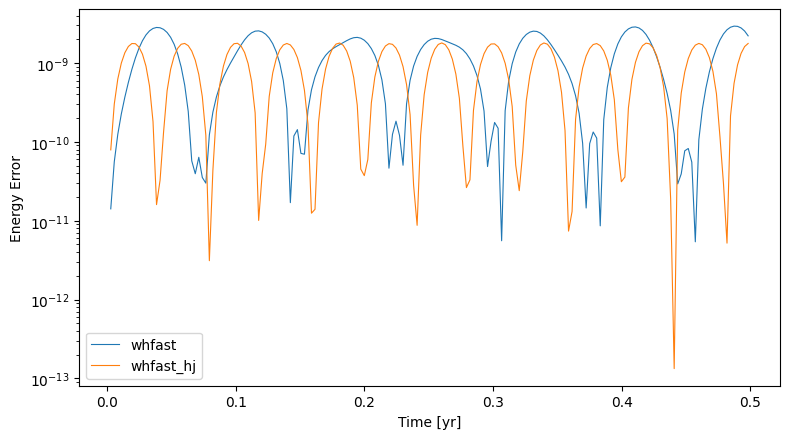

In [38]:
run_1st_experiment(tmax=0.5)

In [50]:
def _circular_binary_state(m_left, m_right, a, phase=0.0, center_r=None, center_v=None):
    if center_r is None:
        center_r = np.zeros(3)
    if center_v is None:
        center_v = np.zeros(3)

    center_r = np.asarray(center_r, dtype=float)
    center_v = np.asarray(center_v, dtype=float)
    total_m = m_left + m_right

    r_hat = np.array([np.cos(phase), np.sin(phase), 0.0])
    t_hat = np.array([-np.sin(phase), np.cos(phase), 0.0])
    rel_r = a * r_hat
    rel_v = np.sqrt(4 * np.pi**2 * total_m / a) * t_hat

    r_left = center_r - (m_right / total_m) * rel_r
    r_right = center_r + (m_left / total_m) * rel_r
    v_left = center_v - (m_right / total_m) * rel_v
    v_right = center_v + (m_left / total_m) * rel_v

    return r_left, v_left, r_right, v_right


def _finish_fixed_system(sim, integrator, dt):
    sim.move_to_com()
    sim.integrator = integrator
    sim.dt = dt
    return sim


def setup_nested_triple(
    m1=0.5,
    m2=0.5,
    m3=0.2,
    a_inner=0.05,
    a_outer=1.0,
    phase_inner=0.0,
    phase_outer=1.0,
    dt=None,
    integrator="whfast_hj",
):
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.G = 4 * np.pi**2

    m12 = m1 + m2
    r12, v12, r3, v3 = _circular_binary_state(m12, m3, a_outer, phase_outer)
    r1, v1, r2, v2 = _circular_binary_state(m1, m2, a_inner, phase_inner, r12, v12)

    sim.add(m=m1, x=r1[0], y=r1[1], z=r1[2], vx=v1[0], vy=v1[1], vz=v1[2])
    sim.add(m=m2, x=r2[0], y=r2[1], z=r2[2], vx=v2[0], vy=v2[1], vz=v2[2])
    sim.add(m=m3, x=r3[0], y=r3[1], z=r3[2], vx=v3[0], vy=v3[1], vz=v3[2])

    if dt is None:
        dt = np.sqrt(a_inner**3 / (m1 + m2)) / 40.0

    return _finish_fixed_system(sim, integrator, dt)


def setup_binary_binary_quadruple(
    m1=0.5,
    m2=0.5,
    m3=0.5,
    m4=0.5,
    a_inner_12=0.08,
    a_inner_34=0.08,
    a_outer=1.0,
    phase_12=0.0,
    phase_34=1.3,
    phase_outer=0.5,
    dt=None,
    integrator="whfast_hj",
):
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.G = 4 * np.pi**2

    m12 = m1 + m2
    m34 = m3 + m4
    r12, v12, r34, v34 = _circular_binary_state(m12, m34, a_outer, phase_outer)
    r1, v1, r2, v2 = _circular_binary_state(m1, m2, a_inner_12, phase_12, r12, v12)
    r3, v3, r4, v4 = _circular_binary_state(m3, m4, a_inner_34, phase_34, r34, v34)

    for m, r, v in [(m1, r1, v1), (m2, r2, v2), (m3, r3, v3), (m4, r4, v4)]:
        sim.add(m=m, x=r[0], y=r[1], z=r[2], vx=v[0], vy=v[1], vz=v[2])

    if dt is None:
        p12 = np.sqrt(a_inner_12**3 / (m1 + m2))
        p34 = np.sqrt(a_inner_34**3 / (m3 + m4))
        dt = min(p12, p34) / 40.0

    return _finish_fixed_system(sim, integrator, dt)


def run_energy_error_for(setup_func, integrator, tmax=10.0, sample_every=1, **setup_kwargs):
    sim = setup_func(integrator=integrator, **setup_kwargs)
    E0 = sim.energy()
    nsteps = int(tmax / sim.dt)

    times = [sim.t]
    energy_errors = [0.0]

    for i in range(nsteps):
        sim.integrate(sim.t + sim.dt)
        if (i + 1) % sample_every == 0 or i == nsteps - 1:
            times.append(sim.t)
            energy_errors.append((sim.energy() - E0) / E0)

    return np.array(times), np.array(energy_errors)


def compare_hj_system(setup_func, tmax=10.0, sample_every=10, running_max=True, **setup_kwargs):
    plt.figure(figsize=(8, 4.5))

    for integrator in ["whfast", "whfast_hj"]:
        times, energy_errors = run_energy_error_for(
            setup_func,
            integrator,
            tmax=tmax,
            sample_every=sample_every,
            **setup_kwargs,
        )
        y = np.abs(energy_errors)
        y[y == 0.0] = np.nan

        if running_max:
            y = np.maximum.accumulate(np.nan_to_num(y, nan=0.0))
            y[y == 0.0] = np.nan

        plt.semilogy(times, y, linewidth=1.0, label=integrator)

    ylabel = "Running max relative energy error" if running_max else "Relative energy error"
    plt.title(setup_func.__name__)
    plt.xlabel("Time [yr]")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()




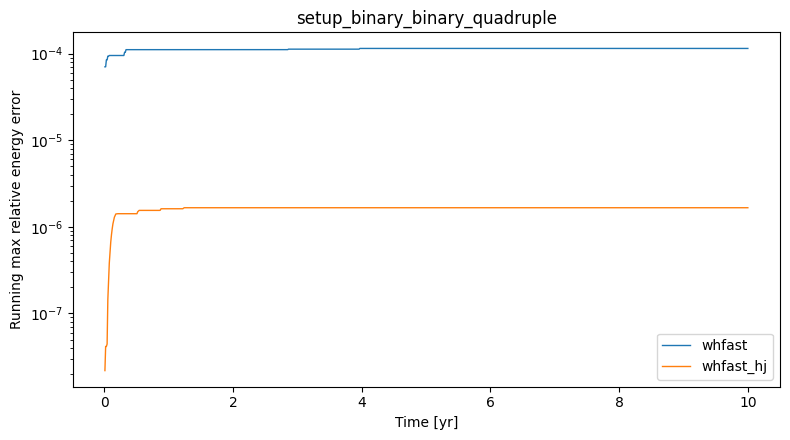

In [43]:
compare_hj_system(setup_binary_binary_quadruple, tmax=10.0, sample_every=20)


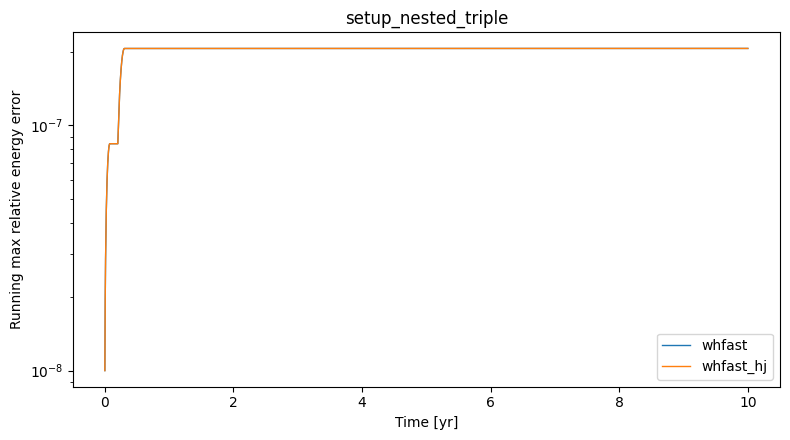

In [51]:
compare_hj_system(setup_nested_triple
, tmax=10.0, sample_every=20)
